In [386]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [387]:
# Load and clean data
df = pd.read_csv("/content/sample_data/Unemployment in India.csv")
df.columns = df.columns.str.strip()  # remove leading/trailing whitespace

In [388]:
# Convert relevant columns to numeric
cols_to_numeric = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]
df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors="coerce")

In [389]:
# Drop rows with missing target
df = df.dropna(subset=["Estimated Unemployment Rate (%)"])

In [390]:
df = df.dropna(how="all")

In [391]:
# --- Feature Engineering ---
df["Estimated Unemployment"] = (
    df["Estimated Employed"] * df["Estimated Unemployment Rate (%)"]
) / (100 - df["Estimated Unemployment Rate (%)"])

df["Labour Force"] = df["Estimated Employed"] + df["Estimated Unemployment"]
df["Working Age Population"] = (
    df["Labour Force"] * 100 / df["Estimated Labour Participation Rate (%)"]
)

In [392]:
# Date Handling
df["Date"] = pd.to_datetime(df["Date"], errors='coerce')
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["DateOrdinal"] = df["Date"].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
df.drop(columns=["Date"], inplace=True)

<ipython-input-392-1094991394>:2: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], errors='coerce')


In [393]:
# Define target and features
target = "Estimated Unemployment Rate (%)"
categorical_cols = ["Region", "Area"]
numerical_cols = [
    "Estimated Employed", "Estimated Labour Participation Rate (%)",
    "Estimated Unemployment", "Labour Force", "Working Age Population",
    "Year", "Month", "Quarter", "DateOrdinal"
]

X = df[categorical_cols + numerical_cols]
y = df[target]

In [394]:
# --- Stratify bins (for regression workaround) ---
y_binned = pd.qcut(y, q=5, labels=False)

In [395]:
# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y_binned, random_state=42
)


In [396]:
# --- Pipelines ---
# Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [401]:
# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])

In [402]:
# Combine into a ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols)
])

In [403]:
# Fit-transform on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [408]:
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)

In [409]:
X_train_df

,num__Estimated Employed,num__Estimated Labour Participation Rate (%),num__Estimated Unemployment,num__Labour Force,num__Working Age Population,num__Year,num__Month,num__Quarter,num__DateOrdinal,cat__Region_Andhra Pradesh,...,cat__Region_Rajasthan,cat__Region_Sikkim,cat__Region_Tamil Nadu,cat__Region_Telangana,cat__Region_Tripura,cat__Region_Uttar Pradesh,cat__Region_Uttarakhand,cat__Region_West Bengal,cat__Area_Rural,cat__Area_Urban
0,-0.871958,0.964691,-0.622843,-0.881076,-0.863377,1.194249,-1.060661,-1.376827,0.900292,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.438756,-0.218086,1.325378,-0.213387,-0.198875,1.194249,-0.451039,-0.442100,1.404218,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.741376,0.617258,-0.388988,-0.729401,-0.733334,-0.837347,0.158584,0.492626,-1.115415,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.179410,0.124330,-0.271389,0.125221,0.074175,-0.837347,-0.146227,-0.442100,-1.371509,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.654162,0.254774,-0.256380,-0.631409,-0.635311,-0.837347,0.158584,0.492626,-1.115415,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,-0.266311,-0.467686,-0.062410,-0.251160,-0.203991,-0.837347,0.768207,0.492626,-0.611488,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
588,-0.308212,-0.767457,-0.492864,-0.349701,-0.269902,-0.837347,-0.146227,-0.442100,-1.371509,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
589,0.929271,-0.546705,-0.146510,0.825286,0.947388,-0.837347,-0.451039,-0.442100,-1.619342,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
590,-0.515647,-0.504060,-0.131362,-0.487787,-0.447501,-0.837347,1.377830,1.427353,-0.107562,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [419]:

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import SGDRegressor

In [420]:
# Parameter grids
param_grids = {
    'RandomForest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 6],
        'learning_rate': [0.05, 0.1]
    },
    'LightGBM': {
        'n_estimators': [100, 200],
        'max_depth': [-1, 10],
        'learning_rate': [0.05, 0.1]
    },
    'CatBoost': {
        'depth': [4, 6],
        'learning_rate': [0.05, 0.1],
        'iterations': [100, 200]
    }
}

# Models
models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(random_state=42),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0)
}

models['SGD'] = SGDRegressor(random_state=42, max_iter=1000)

param_grids['SGD'] = {
    'alpha': [0.0001, 0.001, 0.01],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'eta0': [0.001, 0.01, 0.1]  # Initial learning rate
}

In [421]:
best_models = {}
metrics = {}

for name, model in models.items():
    print(f"Tuning {name}...")
    grid = GridSearchCV(model, param_grids[name], cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X_train_processed, y_train)
    best_model = grid.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test_processed)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5  # Updated here
    r2 = r2_score(y_test, y_pred)
    metrics[name] = {'RMSE': rmse, 'R2 Score': r2}

# Final performance
print("\nModel Performance Summary:")
for model, score in metrics.items():
    print(f"{model}: RMSE = {score['RMSE']:.3f}, R2 Score = {score['R2 Score']:.3f}")

Tuning RandomForest...
Tuning XGBoost...
Tuning LightGBM...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1071
[LightGBM] [Info] Number of data points in the train set: 592, number of used features: 32
[LightGBM] [Info] Start training from score 11.765676
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

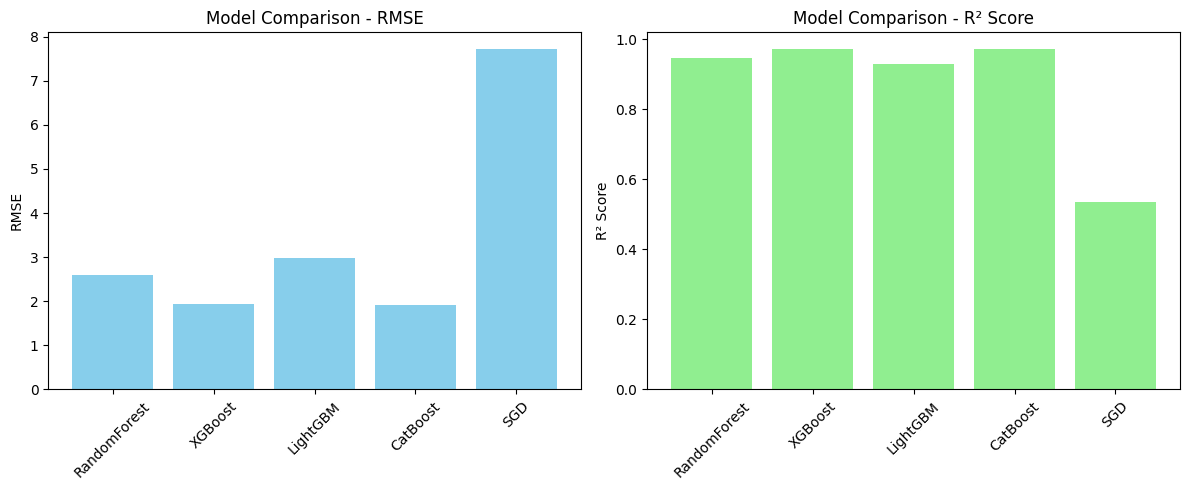

In [422]:
import matplotlib.pyplot as plt

# RMSE plot
rmse_values = [v['RMSE'] for v in metrics.values()]
r2_values = [v['R2 Score'] for v in metrics.values()]
model_names = list(metrics.keys())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(model_names, rmse_values, color='skyblue')
plt.title('Model Comparison - RMSE')
plt.ylabel('RMSE')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(model_names, r2_values, color='lightgreen')
plt.title('Model Comparison - R² Score')
plt.ylabel('R² Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [423]:
import joblib

# Find best model by lowest RMSE
best_model_name = min(metrics, key=lambda x: metrics[x]['RMSE'])
joblib.dump(best_models[best_model_name], f"{best_model_name}_best_model.pkl")

print(f"Best model '{best_model_name}' saved as '{best_model_name}_best_model.pkl'")

Best model 'CatBoost' saved as 'CatBoost_best_model.pkl'


In [424]:
import pandas as pd

# Pick a linear model for interpretability
linear_model = best_models.get('SGD') or best_models.get('LinearRegression')

if linear_model:
    # Get feature names after preprocessing
    feature_names = preprocessor.get_feature_names_out()
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': linear_model.coef_
    }).sort_values(by='Coefficient', key=abs, ascending=False)

    print("\nTop features affecting predictions:")
    print(coef_df.head(10))
else:
    print("No interpretable linear model found (SGD or LinearRegression).")


Top features affecting predictions:
                         Feature  Coefficient
33           cat__Region_Tripura    11.775061
17           cat__Region_Haryana    10.855370
25         cat__Region_Meghalaya    -8.291200
2    num__Estimated Unemployment     6.558626
18  cat__Region_Himachal Pradesh     6.171210
20         cat__Region_Jharkhand     5.389882
30            cat__Region_Sikkim    -4.860035
19   cat__Region_Jammu & Kashmir     4.112061
26            cat__Region_Odisha    -4.110781
38               cat__Area_Urban     3.902750
